# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

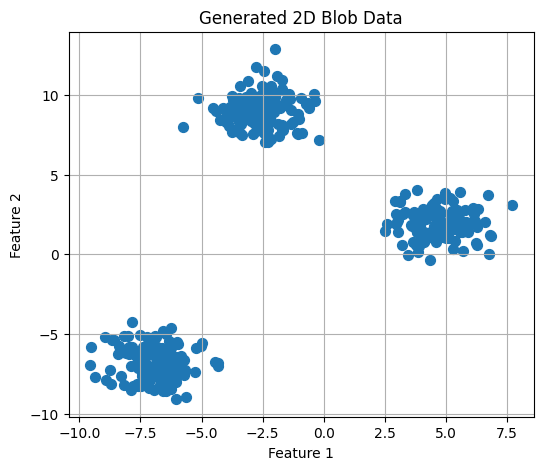

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


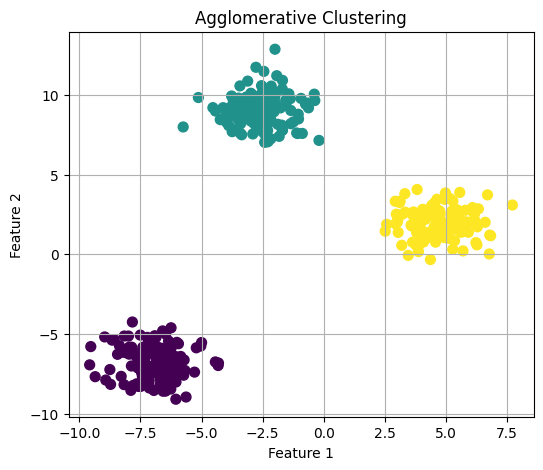

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

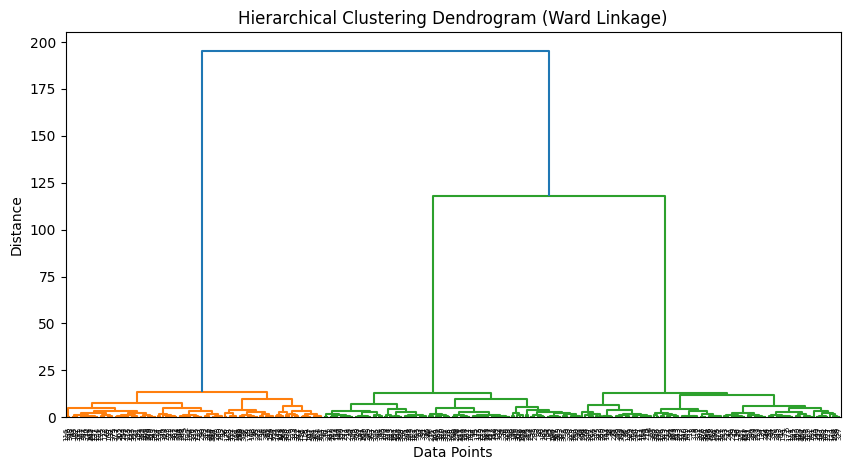

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL.csv


Saving CC GENERAL.csv to CC GENERAL (1).csv
Using file: CC GENERAL (1).csv
Numeric Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical Features: ['CUST_ID']

Numeric Features Distribution:
                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE     

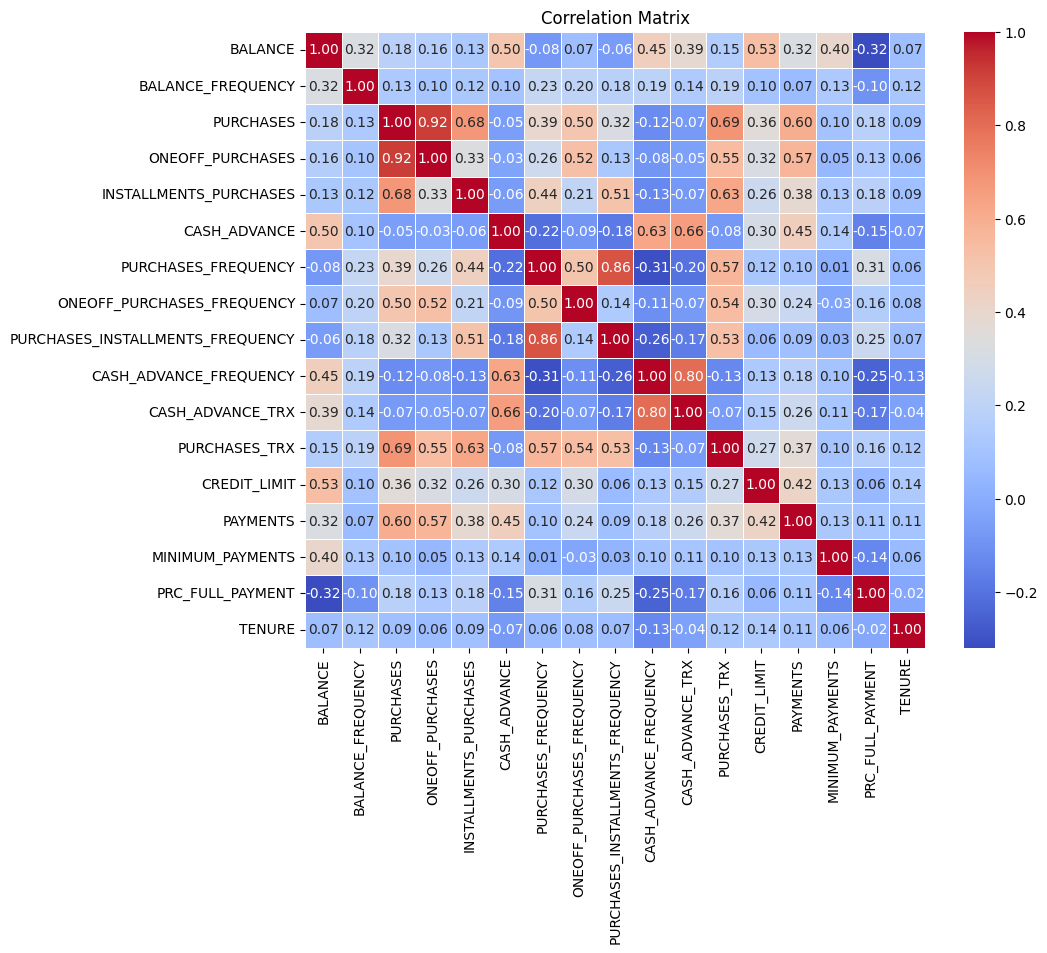

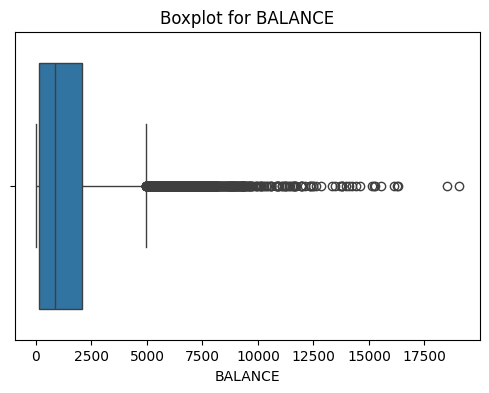

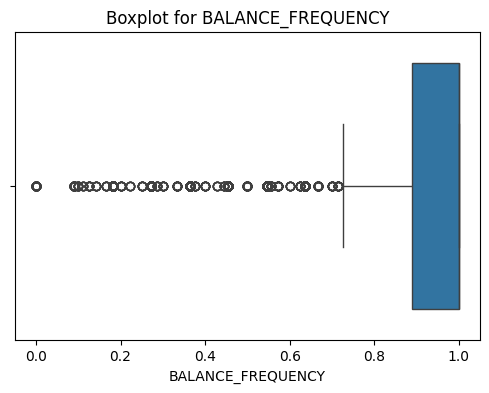

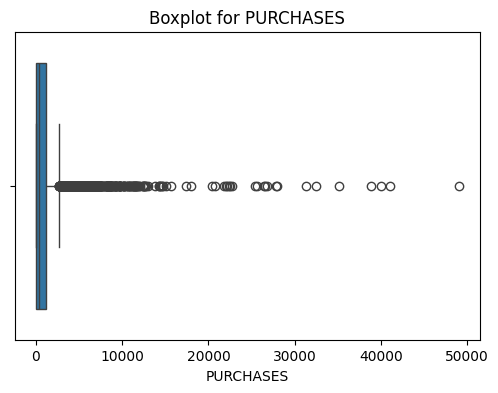

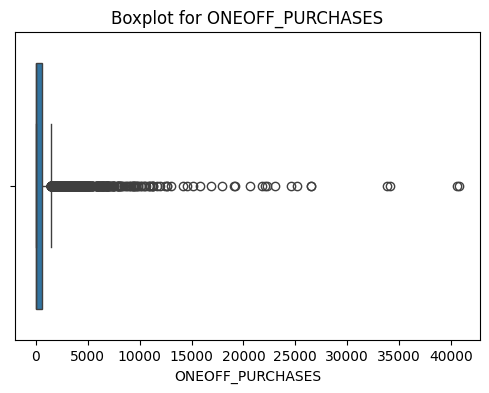

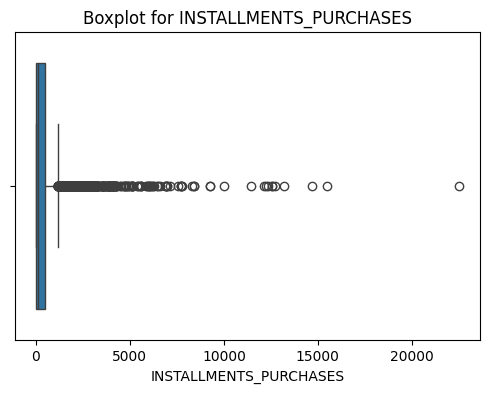

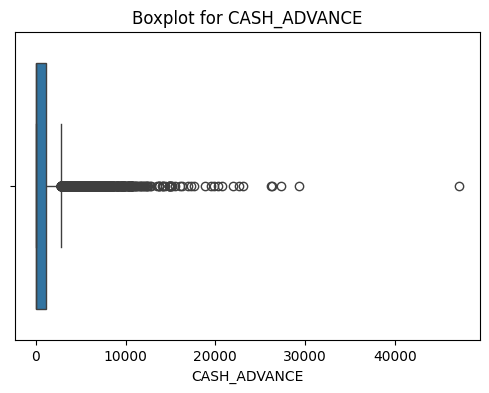

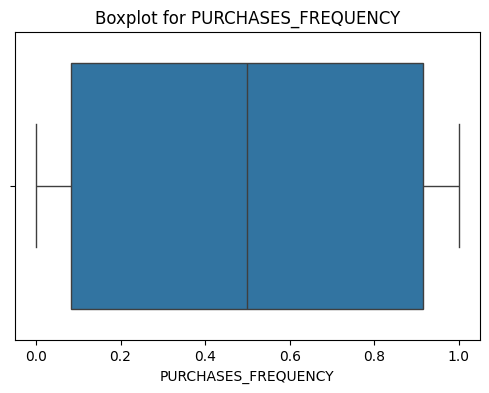

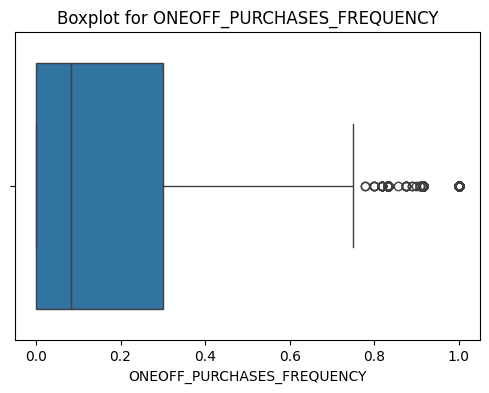

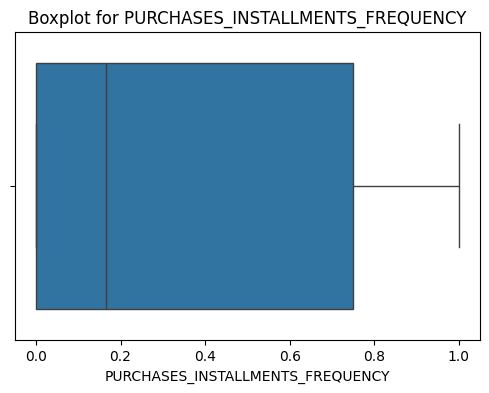

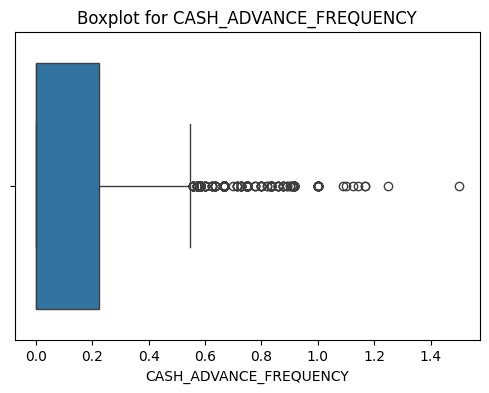

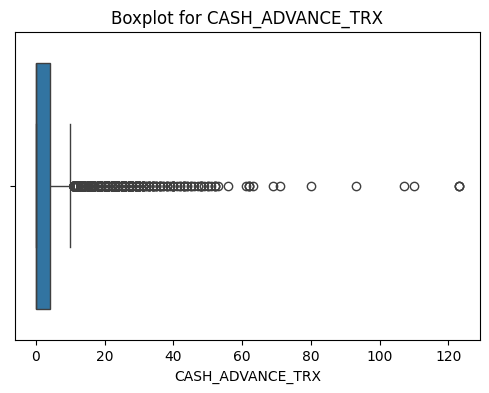

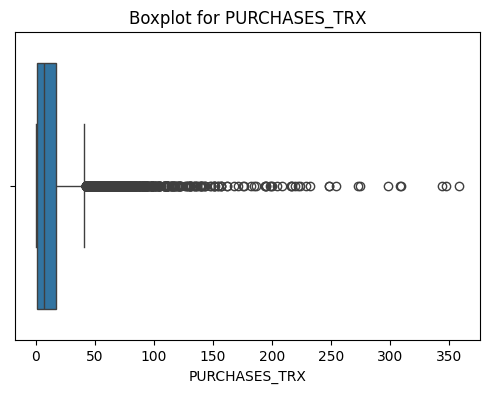

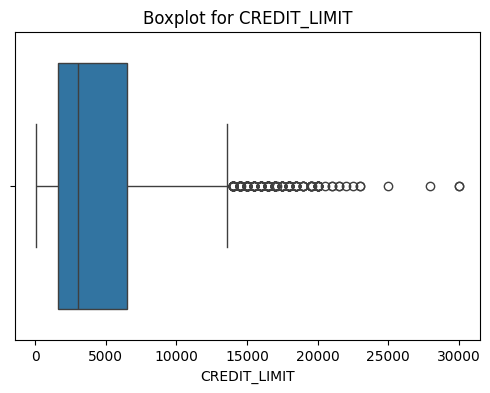

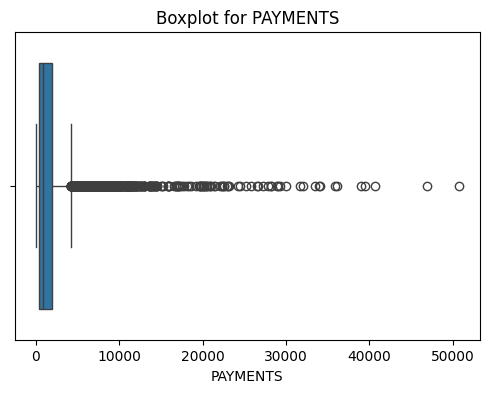

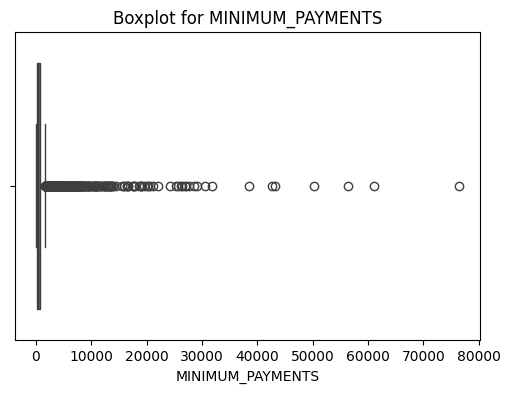

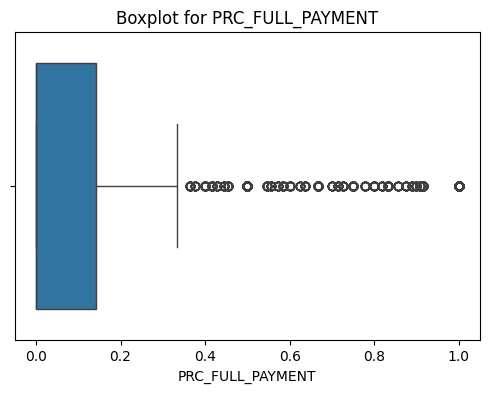

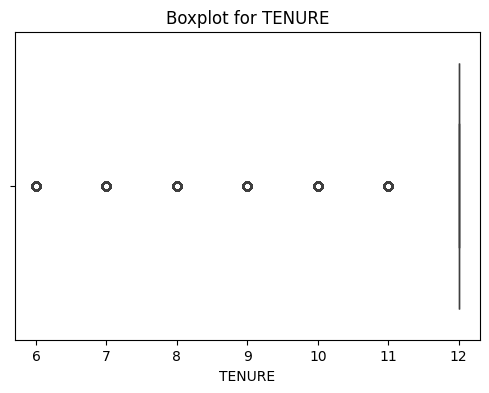

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the uploaded filename
file_path = list(uploaded.keys())[0]
print("Using file:", file_path)

# Load the dataset
data = pd.read_csv(file_path)

# 1. Identify numeric vs categorical features
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# 2. Check distributions of numeric features (min, max, mean, std, skewness)
numeric_summary = data[numeric_features].describe().transpose()
numeric_summary['skewness'] = data[numeric_features].skew()

print("\nNumeric Features Distribution:")
print(numeric_summary)

# 3. Check counts of categories for categorical features
if categorical_features:
    for feature in categorical_features:
        print(f"\nCounts for categorical feature {feature}:")
        print(data[feature].value_counts())

# 4. Identify missing or unknown values
missing_values = data.isnull().sum()
print("\nMissing values per feature:")
print(missing_values[missing_values > 0])

# 5. Handle missing values for numeric columns (fill with median)
# Ensure only numeric columns are filled with the median
data[numeric_features] = data[numeric_features].fillna(data[numeric_features].median())

# 6. Look for correlations between numeric features
correlation_matrix = data[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# 7. Identify outliers that may affect clustering (using boxplots)
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[feature])
    plt.title(f"Boxplot for {feature}")
    plt.show()

## **2. Data Preparation**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Upload the file
from google.colab import files
uploaded = files.upload()

# Get the uploaded filename
file_path = list(uploaded.keys())[0]
print("Using file:", file_path)

# Load the dataset
data = pd.read_csv(file_path)

# 1. Drop irrelevant or target columns
# Let's assume 'CUST_ID' is an irrelevant column to drop
data_cleaned = data.drop(columns=['CUST_ID'])

# 2. Encode categorical features into numeric format
# If there are any categorical features, we'll convert them using pd.get_dummies for one-hot encoding
categorical_features = data_cleaned.select_dtypes(exclude=[np.number]).columns.tolist()

if categorical_features:
    data_cleaned = pd.get_dummies(data_cleaned, columns=categorical_features)

# 3. Scale numeric features so they are comparable for distance calculations
numeric_features = data_cleaned.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
data_cleaned[numeric_features] = scaler.fit_transform(data_cleaned[numeric_features])

# 4. Check for missing values and handle them
missing_values = data_cleaned.isnull().sum()
print("\nMissing values per feature:")
print(missing_values[missing_values > 0])

# Handle missing values by filling with the median (if any)
data_cleaned = data_cleaned.fillna(data_cleaned.median())

# 5. Ensure all features are numeric
# We have already ensured this in previous steps (via scaling and encoding)

# Display the cleaned data (first 5 rows)
print("\nCleaned and Prepared Data (first 5 rows):")
print(data_cleaned.head())

# Final check for missing values
final_missing_values = data_cleaned.isnull().sum()
print("\nFinal Check for Missing Values:")
print(final_missing_values[final_missing_values > 0])

Saving CC GENERAL.csv to CC GENERAL (2).csv
Using file: CC GENERAL (2).csv

Missing values per feature:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Cleaned and Prepared Data (first 5 rows):
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENC

## **3. Apply Agglomerative Clustering**

Agglomerative Clustering Results:
cluster
1    4267
0    3529
2    1154
Name: count, dtype: int64


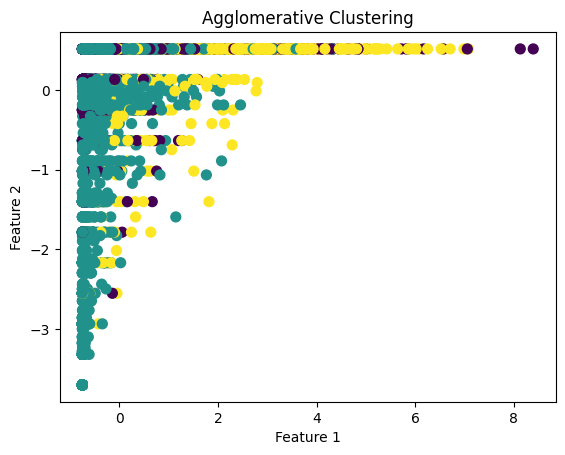

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Parameters for Agglomerative Clustering
n_clusters = 3  # Set the number of clusters you want
metric = 'euclidean'  # Choose the distance metric (e.g., 'euclidean', 'manhattan')
linkage = 'ward'  # Linkage method (e.g., 'ward', 'complete', 'average')

# If using 'ward', no need to set 'affinity', remove it
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)

# Apply Agglomerative Clustering (after data preparation)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)

# Fit the model and predict clusters using the prepared data (data_cleaned)
data_cleaned['cluster'] = agg_clustering.fit_predict(data_cleaned)

# Display the resulting clusters
print("Agglomerative Clustering Results:")
print(data_cleaned['cluster'].value_counts())

# Visualizing the clusters (using the first two features for simplicity)
plt.scatter(data_cleaned.iloc[:, 0], data_cleaned.iloc[:, 1], c=data_cleaned['cluster'], cmap='viridis', s=50)
plt.title("Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## **4. Visualize the Clustering Results**

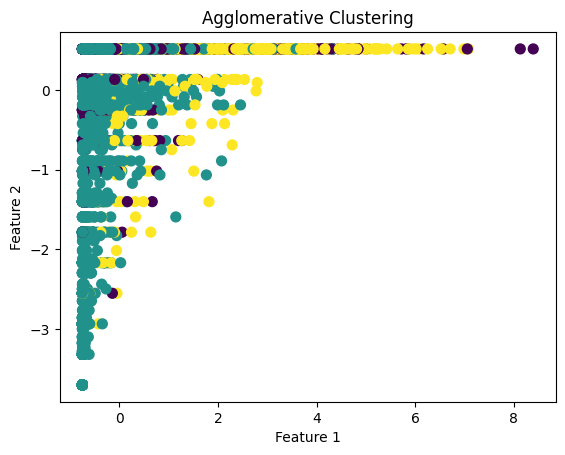

In [ ]:
# Visualize the clustering results using the first two features for simplicity
plt.scatter(data_cleaned.iloc[:, 0], data_cleaned.iloc[:, 1], c=data_cleaned['cluster'], cmap='viridis', s=50)
plt.title("Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

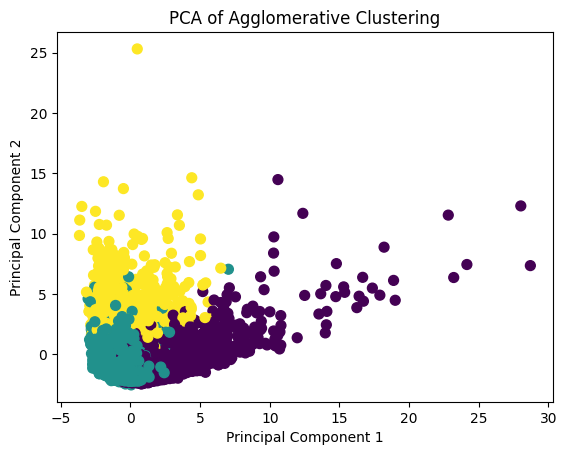

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction (reduce to 2 components for visualization)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_cleaned)

# Plot the reduced data
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=data_cleaned['cluster'], cmap='viridis', s=50)
plt.title("PCA of Agglomerative Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## **5. Evaluate the Clustering**

Cluster Characteristics:

Cluster 0:
           BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
count  3529.000000        3529.000000  3529.000000       3529.000000   
mean     -0.140187           0.381911     0.460368          0.337513   
std       0.850043           0.384432     1.421660          1.481625   
min      -0.751640          -3.703271    -0.469552         -0.356934   
25%      -0.685382           0.518084    -0.229689         -0.356934   
50%      -0.446327           0.518084     0.043026         -0.114916   
75%       0.058909           0.518084     0.621664          0.462378   
max       8.397489           0.518084    22.483510         24.201066   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             3529.000000   3529.000000          3529.000000   
mean                 0.468308     -0.328554             0.912369   
std                  1.392111      0.422214             0.480674   
min                 -0.454576     -0.46678

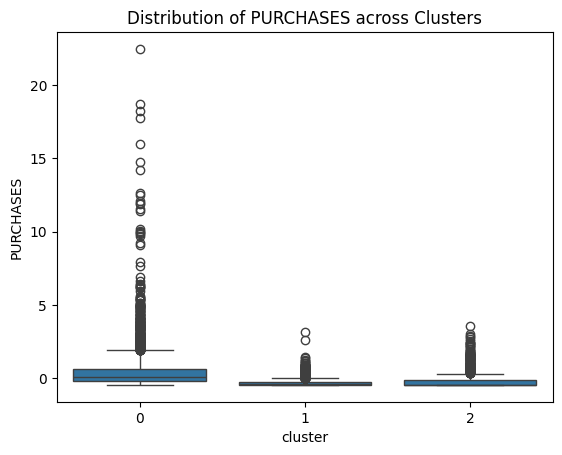


Silhouette Score: 0.16746568706698886


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Analyze the characteristics of each cluster
print("Cluster Characteristics:")
for cluster_id in np.unique(data_cleaned['cluster']):
    print(f"\nCluster {cluster_id}:")
    cluster_data = data_cleaned[data_cleaned['cluster'] == cluster_id]
    print(cluster_data.describe())

# 2. Visualize the distribution of a specific feature (e.g., 'PURCHASES')
sns.boxplot(x='cluster', y='PURCHASES', data=data_cleaned)
plt.title("Distribution of PURCHASES across Clusters")
plt.show()

# 3. Compute Silhouette Score (only works with numerical data)
sil_score = silhouette_score(data_cleaned.drop(columns=['cluster']), data_cleaned['cluster'])
print(f"\nSilhouette Score: {sil_score}")

# 4. If you have ground truth labels, you can calculate Adjusted Rand Index (ARI)
# Uncomment if you have true labels
# true_labels = [your_true_labels]  # Replace this with actual true labels if available
# from sklearn.metrics import adjusted_rand_score
# ari_score = adjusted_rand_score(true_labels, data_cleaned['cluster'])
# print(f"Adjusted Rand Index (ARI): {ari_score}")

## **6. Explain whether the clustering quality and justify your reasoning**